# 05 - Detector custom multi-objeto (NEU-DET)

Implementacion desde cero (sin torchvision.models y sin ultralytics).

Salida tipo rejilla: [B, S, S, 5 + C] con S=7 y C=6.
Cada celda predice objectness + bbox + clase.

## 1) Imports y verificacion de kernel
Este notebook esta pensado para tu kernel tfm_steel_311.

In [17]:
from pathlib import Path
from typing import List, Optional, Sequence, Tuple
import platform

import cv2
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset

print(f"Python activo: {platform.python_version()} | Kernel esperado: tfm_steel_311")
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo: {DEVICE}")

NEU_CLASSES = [
    "crazing",
    "inclusion",
    "patches",
    "pitted_surface",
    "rolled-in_scale",
    "scratches",
]

Python activo: 3.11.15 | Kernel esperado: tfm_steel_311
Dispositivo: cuda


## 2) Arquitectura custom
Backbone: Conv2d + BatchNorm2d + LeakyReLU + MaxPool2d.
Head: Conv final que produce [B, S, S, 5 + C].

In [18]:
class ConvBlock(nn.Module):
    def __init__(self, in_ch: int, out_ch: int) -> None:
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.LeakyReLU(negative_slope=0.1, inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.block(x)


class CustomSteelDetector(nn.Module):
    """
    Entrada: [B, 3, 224, 224]
    Salida:  [B, S, S, 5 + C]

    Canales por celda:
    [0] objectness
    [1] x relativo a la celda
    [2] y relativo a la celda
    [3] width normalizado
    [4] height normalizado
    [5:] logits de clase
    """

    def __init__(self, s: int = 7, num_classes: int = 6) -> None:
        super().__init__()
        self.s = s
        self.num_classes = num_classes

        self.backbone = nn.Sequential(
            ConvBlock(3, 32),
            ConvBlock(32, 64),
            ConvBlock(64, 128),
            ConvBlock(128, 256),
            ConvBlock(256, 512),
            nn.Conv2d(512, 512, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(512),
            nn.LeakyReLU(negative_slope=0.1, inplace=True),
        )

        self.head = nn.Conv2d(512, 5 + num_classes, kernel_size=1, stride=1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.backbone(x)
        x = self.head(x)
        x = x.permute(0, 2, 3, 1)
        return x

## 3) Dataset multi-objeto con rejilla
Cada objeto se asigna a la celda (i, j) segun su centro normalizado.
Esto permite multiples defectos por imagen.

In [19]:
class NEUGridDataset(Dataset):
    """
    Lee etiquetas YOLO co-localizadas con las imágenes dentro de cada split/clase.

    Estructura esperada (ejemplo train):
    data/clasificacion_full/crazing/xxx.jpg + xxx.txt
    data/clasificacion_full/inclusion/yyy.jpg + yyy.txt
    ...

    Logica de rejilla SxS:
    - gx = x_center * S, gy = y_center * S
    - j = floor(gx), i = floor(gy)
    - x_cell = gx - j, y_cell = gy - i
    """

    def __init__(
        self,
        split_dir: Path,
        image_size: int = 224,
        s: int = 7,
        num_classes: int = 6,
    ) -> None:
        self.split_dir = split_dir
        self.image_size = image_size
        self.s = s
        self.num_classes = num_classes

        self.valid_ext = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp"}
        all_label_files = sorted(self.split_dir.rglob("*.txt"))
        if not all_label_files:
            raise FileNotFoundError(f"No hay etiquetas en: {self.split_dir}")

        # Pre-construye pares válidos label->image para evitar fallos en workers.
        self.samples: List[Tuple[Path, Path]] = []
        skipped = 0
        for label_path in all_label_files:
            image_path = self._find_image_for_label(label_path, raise_if_missing=False)
            if image_path is None:
                skipped += 1
                continue
            self.samples.append((label_path, image_path))

        if not self.samples:
            raise FileNotFoundError(
                f"No se encontraron pares válidos imagen-etiqueta en: {self.split_dir} "
                f"(labels={len(all_label_files)}, skipped={skipped})"
            )

        if skipped > 0:
            print(f"[WARN] Etiquetas sin imagen asociada ignoradas: {skipped}")
        print(f"Dataset listo: {len(self.samples)} muestras válidas")

    def __len__(self) -> int:
        return len(self.samples)

    def _find_image_for_label(self, label_path: Path, raise_if_missing: bool = True) -> Optional[Path]:
        stem = label_path.stem

        # Primero buscar junto al .txt (convención principal).
        for c in sorted(label_path.parent.glob(f"{stem}.*")):
            if c.suffix.lower() in self.valid_ext and c.is_file():
                return c

        # Fallback por si hay separaciones no previstas.
        for c in sorted(self.split_dir.rglob(f"{stem}.*")):
            if c.suffix.lower() in self.valid_ext and c.is_file():
                return c

        if raise_if_missing:
            raise FileNotFoundError(f"No se encontro imagen para etiqueta: {label_path}")
        return None

    def _load_image(self, image_path: Path) -> torch.Tensor:
        img_bgr = cv2.imread(str(image_path), cv2.IMREAD_COLOR)
        if img_bgr is None:
            raise ValueError(f"No se pudo leer imagen: {image_path}")

        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        img_rgb = cv2.resize(img_rgb, (self.image_size, self.image_size), interpolation=cv2.INTER_LINEAR)
        img = img_rgb.astype(np.float32) / 255.0

        mean = np.array([0.485, 0.456, 0.406], dtype=np.float32)
        std = np.array([0.229, 0.224, 0.225], dtype=np.float32)
        img = (img - mean) / std

        return torch.from_numpy(img).permute(2, 0, 1).contiguous()

    def _read_boxes(self, label_path: Path) -> List[Tuple[int, float, float, float, float]]:
        boxes = []
        for line in label_path.read_text(encoding="utf-8").splitlines():
            if not line.strip():
                continue
            c, x, y, w, h = line.split()
            boxes.append((int(c), float(x), float(y), float(w), float(h)))
        return boxes

    def _build_target(self, boxes: Sequence[Tuple[int, float, float, float, float]]) -> torch.Tensor:
        target = torch.zeros((self.s, self.s, 5 + self.num_classes), dtype=torch.float32)

        for class_id, x_center, y_center, width, height in boxes:
            gx = x_center * self.s
            gy = y_center * self.s
            j = min(self.s - 1, max(0, int(gx)))
            i = min(self.s - 1, max(0, int(gy)))

            x_cell = gx - j
            y_cell = gy - i

            # Si varios objetos caen en la misma celda, mantenemos el de mayor area.
            if target[i, j, 0] > 0:
                prev_w = float(target[i, j, 3].item())
                prev_h = float(target[i, j, 4].item())
                if prev_w * prev_h >= width * height:
                    continue

            target[i, j, 0] = 1.0
            target[i, j, 1] = x_cell
            target[i, j, 2] = y_cell
            target[i, j, 3] = width
            target[i, j, 4] = height
            target[i, j, 5:] = 0.0
            if 0 <= class_id < self.num_classes:
                target[i, j, 5 + class_id] = 1.0

        return target

    def __getitem__(self, idx: int) -> Tuple[torch.Tensor, torch.Tensor]:
        label_path, image_path = self.samples[idx]
        image = self._load_image(image_path)
        boxes = self._read_boxes(label_path)
        target = self._build_target(boxes)
        return image, target

## 4) Loss custom
MSE para confianza y cajas, y CrossEntropy para clase solo en celdas con objeto.

In [20]:
class CustomDetectionLoss(nn.Module):
    def __init__(
        self,
        lambda_coord: float = 5.0,
        lambda_obj: float = 1.0,
        lambda_noobj: float = 0.5,
        lambda_cls: float = 1.0,
    ) -> None:
        super().__init__()
        self.lambda_coord = lambda_coord
        self.lambda_obj = lambda_obj
        self.lambda_noobj = lambda_noobj
        self.lambda_cls = lambda_cls

    def forward(self, preds: torch.Tensor, target: torch.Tensor) -> torch.Tensor:
        obj_mask = target[..., 0] > 0.5
        noobj_mask = ~obj_mask

        pred_conf = torch.sigmoid(preds[..., 0])
        pred_xywh = torch.sigmoid(preds[..., 1:5])
        pred_cls = preds[..., 5:]

        tgt_conf = target[..., 0]
        tgt_xywh = target[..., 1:5]

        if obj_mask.any():
            loss_xywh = F.mse_loss(pred_xywh[obj_mask], tgt_xywh[obj_mask], reduction="mean")
            loss_obj = F.mse_loss(pred_conf[obj_mask], tgt_conf[obj_mask], reduction="mean")
            target_cls_idx = torch.argmax(target[..., 5:], dim=-1)
            loss_cls = F.cross_entropy(pred_cls[obj_mask], target_cls_idx[obj_mask], reduction="mean")
        else:
            loss_xywh = torch.tensor(0.0, device=preds.device)
            loss_obj = torch.tensor(0.0, device=preds.device)
            loss_cls = torch.tensor(0.0, device=preds.device)

        if noobj_mask.any():
            loss_noobj = F.mse_loss(pred_conf[noobj_mask], tgt_conf[noobj_mask], reduction="mean")
        else:
            loss_noobj = torch.tensor(0.0, device=preds.device)

        return (
            self.lambda_coord * loss_xywh
            + self.lambda_obj * loss_obj
            + self.lambda_noobj * loss_noobj
            + self.lambda_cls * loss_cls
        )

## 5) Entrenamiento (CUDA optimizado)

In [21]:
from contextlib import nullcontext

def get_amp_tools(device: torch.device):
    """Compatibilidad AMP para distintas versiones de PyTorch."""
    if device.type != "cuda":
        return None, None, nullcontext

    try:
        autocast_fn = torch.amp.autocast
        scaler_obj = torch.amp.GradScaler("cuda")

        def autocast_ctx():
            return autocast_fn(device_type="cuda", dtype=torch.float16)

        return autocast_fn, scaler_obj, autocast_ctx
    except (AttributeError, TypeError):
        autocast_fn = torch.cuda.amp.autocast
        scaler_obj = torch.cuda.amp.GradScaler()

        def autocast_ctx():
            return autocast_fn(dtype=torch.float16)

        return autocast_fn, scaler_obj, autocast_ctx


def train_one_epoch(
    model: nn.Module,
    loader: DataLoader,
    criterion: nn.Module,
    optimizer: torch.optim.Optimizer,
    device: torch.device,
    scaler: Optional[object],
    autocast_ctx,
) -> float:
    model.train()
    running_loss = 0.0

    for images, targets in loader:
        images = images.to(device, non_blocking=True)
        targets = targets.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        if scaler is not None:
            with autocast_ctx():
                preds = model(images)
                loss = criterion(preds, targets)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            preds = model(images)
            loss = criterion(preds, targets)
            loss.backward()
            optimizer.step()

        running_loss += float(loss.item()) * images.size(0)

    return running_loss / len(loader.dataset)


def save_checkpoint(model: nn.Module, class_names: Sequence[str], s: int, image_size: int, save_path: Path) -> None:
    save_path.parent.mkdir(parents=True, exist_ok=True)
    torch.save(
        {
            "model_state_dict": model.state_dict(),
            "class_names": list(class_names),
            "s": s,
            "num_classes": len(class_names),
            "image_size": image_size,
        },
        save_path,
    )


# Split de entrenamiento en tu estructura actual
TRAIN_DIR = Path("../data/clasificacion_full")
EPOCHS = 100
BATCH_SIZE = 16
NUM_WORKERS = 0  # En Windows evita caidas silenciosas de workers
LR = 1e-3
IMAGE_SIZE = 224
GRID_SIZE = 7
SAVE_PATH = Path("../src/custom_steel_detector_grid7.pth")

dataset = NEUGridDataset(
    split_dir=TRAIN_DIR,
    image_size=IMAGE_SIZE,
    s=GRID_SIZE,
    num_classes=len(NEU_CLASSES),
)

loader = DataLoader(
    dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
    drop_last=False,
)

model = CustomSteelDetector(s=GRID_SIZE, num_classes=len(NEU_CLASSES)).to(DEVICE)
criterion = CustomDetectionLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
_, scaler, autocast_ctx = get_amp_tools(DEVICE)

for epoch in range(1, EPOCHS + 1):
    avg_loss = train_one_epoch(model, loader, criterion, optimizer, DEVICE, scaler, autocast_ctx)
    print(f"Epoch {epoch}/{EPOCHS} | loss: {avg_loss:.6f}")

save_checkpoint(model, NEU_CLASSES, GRID_SIZE, IMAGE_SIZE, SAVE_PATH)
print(f"Modelo guardado en: {SAVE_PATH.resolve()}")

Dataset listo: 1439 muestras válidas
Epoch 1/100 | loss: 1.302128
Epoch 2/100 | loss: 0.851671
Epoch 3/100 | loss: 0.717050
Epoch 4/100 | loss: 0.638543
Epoch 5/100 | loss: 0.535197
Epoch 6/100 | loss: 0.528521
Epoch 7/100 | loss: 0.514594
Epoch 8/100 | loss: 0.435561
Epoch 9/100 | loss: 0.397967
Epoch 10/100 | loss: 0.391899
Epoch 11/100 | loss: 0.367762
Epoch 12/100 | loss: 0.335299
Epoch 13/100 | loss: 0.304360
Epoch 14/100 | loss: 0.307128
Epoch 15/100 | loss: 0.268175
Epoch 16/100 | loss: 0.261740
Epoch 17/100 | loss: 0.232462
Epoch 18/100 | loss: 0.198663
Epoch 19/100 | loss: 0.197429
Epoch 20/100 | loss: 0.246307
Epoch 21/100 | loss: 0.265561
Epoch 22/100 | loss: 0.171407
Epoch 23/100 | loss: 0.147135
Epoch 24/100 | loss: 0.130646
Epoch 25/100 | loss: 0.128530
Epoch 26/100 | loss: 0.140317
Epoch 27/100 | loss: 0.231416
Epoch 28/100 | loss: 0.133664
Epoch 29/100 | loss: 0.105506
Epoch 30/100 | loss: 0.091956
Epoch 31/100 | loss: 0.076335
Epoch 32/100 | loss: 0.062968
Epoch 33/100

## 6) Inferencia y visualizacion
Usa threshold de confianza y dibuja todas las detecciones con cv2.rectangle.

In [22]:
def _iou_xyxy(box_a, box_b) -> float:
    ax1, ay1, ax2, ay2 = box_a
    bx1, by1, bx2, by2 = box_b

    inter_x1 = max(ax1, bx1)
    inter_y1 = max(ay1, by1)
    inter_x2 = min(ax2, bx2)
    inter_y2 = min(ay2, by2)

    inter_w = max(0, inter_x2 - inter_x1)
    inter_h = max(0, inter_y2 - inter_y1)
    inter_area = inter_w * inter_h

    area_a = max(0, ax2 - ax1) * max(0, ay2 - ay1)
    area_b = max(0, bx2 - bx1) * max(0, by2 - by1)
    union = area_a + area_b - inter_area
    if union <= 0:
        return 0.0
    return inter_area / union


def nms_per_class(dets: List[Tuple[float, int, int, int, int, int]], iou_thr: float = 0.40):
    """NMS por clase para reducir cajas superpuestas (máximo 40% de solape)."""
    kept = []
    by_class = {}
    for d in dets:
        by_class.setdefault(d[1], []).append(d)

    for _, class_dets in by_class.items():
        class_dets = sorted(class_dets, key=lambda x: x[0], reverse=True)
        while class_dets:
            best = class_dets.pop(0)
            kept.append(best)

            remain = []
            best_box = (best[2], best[3], best[4], best[5])
            for d in class_dets:
                cur_box = (d[2], d[3], d[4], d[5])
                if _iou_xyxy(best_box, cur_box) < iou_thr:
                    remain.append(d)
            class_dets = remain

    kept = sorted(kept, key=lambda x: x[0], reverse=True)
    return kept


def decode_predictions(
    pred_grid: torch.Tensor,
    threshold: float,
    s: int,
    image_w: int,
    image_h: int,
    nms_iou_thr: float = 0.40,
) -> List[Tuple[float, int, int, int, int, int]]:
    dets = []
    pred_grid = pred_grid.detach().cpu()

    for i in range(s):
        for j in range(s):
            conf = torch.sigmoid(pred_grid[i, j, 0]).item()
            if conf < threshold:
                continue

            x_cell = torch.sigmoid(pred_grid[i, j, 1]).item()
            y_cell = torch.sigmoid(pred_grid[i, j, 2]).item()
            w_norm = torch.sigmoid(pred_grid[i, j, 3]).item()
            h_norm = torch.sigmoid(pred_grid[i, j, 4]).item()
            class_id = int(torch.argmax(pred_grid[i, j, 5:]).item())

            x_center = (j + x_cell) / s
            y_center = (i + y_cell) / s

            x1 = int((x_center - w_norm / 2.0) * image_w)
            y1 = int((y_center - h_norm / 2.0) * image_h)
            x2 = int((x_center + w_norm / 2.0) * image_w)
            y2 = int((y_center + h_norm / 2.0) * image_h)

            x1 = max(0, min(image_w - 1, x1))
            y1 = max(0, min(image_h - 1, y1))
            x2 = max(0, min(image_w - 1, x2))
            y2 = max(0, min(image_h - 1, y2))

            if x2 <= x1 or y2 <= y1:
                continue

            dets.append((conf, class_id, x1, y1, x2, y2))

    return nms_per_class(dets, iou_thr=nms_iou_thr)


def run_inference(
    weights: Path,
    image_path: Path,
    output_path: Path,
    threshold: float = 0.35,
    nms_iou_thr: float = 0.40,
) -> None:
    ckpt = torch.load(weights, map_location=DEVICE)
    class_names = ckpt.get("class_names", NEU_CLASSES)
    s = int(ckpt.get("s", 7))
    num_classes = int(ckpt.get("num_classes", len(class_names)))
    image_size = int(ckpt.get("image_size", 224))

    model = CustomSteelDetector(s=s, num_classes=num_classes).to(DEVICE)
    model.load_state_dict(ckpt["model_state_dict"] )
    model.eval()

    raw = cv2.imread(str(image_path), cv2.IMREAD_COLOR)
    if raw is None:
        raise ValueError(f"No se pudo leer imagen: {image_path}")

    h, w = raw.shape[:2]
    rgb = cv2.cvtColor(raw, cv2.COLOR_BGR2RGB)
    resized = cv2.resize(rgb, (image_size, image_size), interpolation=cv2.INTER_LINEAR).astype(np.float32) / 255.0

    mean = np.array([0.485, 0.456, 0.406], dtype=np.float32)
    std = np.array([0.229, 0.224, 0.225], dtype=np.float32)
    resized = (resized - mean) / std

    x = torch.from_numpy(resized).permute(2, 0, 1).unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        pred = model(x)[0]

    dets = decode_predictions(
        pred,
        threshold,
        s,
        image_size,
        image_size,
        nms_iou_thr=nms_iou_thr,
    )

    sx = w / float(image_size)
    sy = h / float(image_size)

    vis = raw.copy()
    for conf, class_id, x1, y1, x2, y2 in dets:
        rx1 = int(x1 * sx)
        ry1 = int(y1 * sy)
        rx2 = int(x2 * sx)
        ry2 = int(y2 * sy)

        cv2.rectangle(vis, (rx1, ry1), (rx2, ry2), (0, 255, 0), 2)
        class_name = class_names[class_id] if class_id < len(class_names) else str(class_id)
        cv2.putText(vis, f"{class_name}:{conf:.2f}", (rx1, max(12, ry1 - 6)), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 1)

    output_path.parent.mkdir(parents=True, exist_ok=True)
    cv2.imwrite(str(output_path), vis)
    print(f"Detecciones tras NMS: {len(dets)}")
    print(f"Resultado guardado en: {output_path.resolve()}")


WEIGHTS = Path("../src/custom_steel_detector_grid7.pth")
TEST_IMAGE = Path("../data/test/crazing/ejemplo.jpg")
OUTPUT_IMAGE = Path("../resultados/deteccion_test.jpg")
THRESHOLD = 0.35
NMS_IOU_THR = 0.40

# Ejecuta cuando tengas un modelo entrenado y una imagen real.
# run_inference(WEIGHTS, TEST_IMAGE, OUTPUT_IMAGE, THRESHOLD, NMS_IOU_THR)

## 7) Evaluación estilo YOLO en TEST

> Esta sección calcula métricas de detección: Precision, Recall, F1, AP50 por clase y mAP50.

In [23]:
import random
from collections import defaultdict
import matplotlib.pyplot as plt

def yolo_to_xyxy(xc: float, yc: float, w: float, h: float, img_w: int, img_h: int):
    x1 = int((xc - w / 2.0) * img_w)
    y1 = int((yc - h / 2.0) * img_h)
    x2 = int((xc + w / 2.0) * img_w)
    y2 = int((yc + h / 2.0) * img_h)
    x1 = max(0, min(img_w - 1, x1))
    y1 = max(0, min(img_h - 1, y1))
    x2 = max(0, min(img_w - 1, x2))
    y2 = max(0, min(img_h - 1, y2))
    return x1, y1, x2, y2


def compute_iou(box_a, box_b) -> float:
    ax1, ay1, ax2, ay2 = box_a
    bx1, by1, bx2, by2 = box_b

    inter_x1 = max(ax1, bx1)
    inter_y1 = max(ay1, by1)
    inter_x2 = min(ax2, bx2)
    inter_y2 = min(ay2, by2)

    inter_w = max(0, inter_x2 - inter_x1)
    inter_h = max(0, inter_y2 - inter_y1)
    inter_area = inter_w * inter_h

    area_a = max(0, ax2 - ax1) * max(0, ay2 - ay1)
    area_b = max(0, bx2 - bx1) * max(0, by2 - by1)
    union = area_a + area_b - inter_area

    if union <= 0:
        return 0.0
    return inter_area / union


def load_gt_boxes_for_image(image_path: Path):
    txt_path = image_path.with_suffix(".txt")
    if not txt_path.exists():
        return []

    img = cv2.imread(str(image_path), cv2.IMREAD_COLOR)
    if img is None:
        return []
    h, w = img.shape[:2]

    gts = []
    for line in txt_path.read_text(encoding="utf-8").splitlines():
        if not line.strip():
            continue
        c, xc, yc, bw, bh = line.split()
        class_id = int(c)
        box = yolo_to_xyxy(float(xc), float(yc), float(bw), float(bh), w, h)
        gts.append({"class_id": class_id, "box": box})
    return gts


def list_test_images(test_root: Path):
    valid_ext = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp"}
    images = []
    for p in sorted(test_root.rglob("*")):
        if p.suffix.lower() in valid_ext and p.is_file():
            images.append(p)
    return images


def predict_boxes_for_image(model: nn.Module, image_path: Path, threshold: float = 0.25):
    raw = cv2.imread(str(image_path), cv2.IMREAD_COLOR)
    if raw is None:
        return []

    h, w = raw.shape[:2]
    ckpt_image_size = 224

    rgb = cv2.cvtColor(raw, cv2.COLOR_BGR2RGB)
    resized = cv2.resize(rgb, (ckpt_image_size, ckpt_image_size), interpolation=cv2.INTER_LINEAR).astype(np.float32) / 255.0
    mean = np.array([0.485, 0.456, 0.406], dtype=np.float32)
    std = np.array([0.229, 0.224, 0.225], dtype=np.float32)
    resized = (resized - mean) / std

    x = torch.from_numpy(resized).permute(2, 0, 1).unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        pred = model(x)[0]

    dets = decode_predictions(pred, threshold=threshold, s=7, image_w=ckpt_image_size, image_h=ckpt_image_size)
    sx = w / float(ckpt_image_size)
    sy = h / float(ckpt_image_size)

    preds = []
    for conf, class_id, x1, y1, x2, y2 in dets:
        rx1 = int(x1 * sx)
        ry1 = int(y1 * sy)
        rx2 = int(x2 * sx)
        ry2 = int(y2 * sy)
        preds.append({
            "conf": float(conf),
            "class_id": int(class_id),
            "box": (rx1, ry1, rx2, ry2),
        })
    return preds


def evaluate_detector_yolo_style(weights: Path, test_root: Path, threshold: float = 0.25, iou_thr: float = 0.5, max_images: Optional[int] = None):
    ckpt = torch.load(weights, map_location=DEVICE)
    class_names = ckpt.get("class_names", NEU_CLASSES)
    s = int(ckpt.get("s", 7))
    num_classes = int(ckpt.get("num_classes", len(class_names)))

    model = CustomSteelDetector(s=s, num_classes=num_classes).to(DEVICE)
    model.load_state_dict(ckpt["model_state_dict"])
    model.eval()

    images = list_test_images(test_root)
    if max_images is not None:
        images = images[:max_images]

    gt_count = defaultdict(int)
    pred_records = defaultdict(list)
    matched_ious = []

    for image_path in images:
        gts = load_gt_boxes_for_image(image_path)
        preds = predict_boxes_for_image(model, image_path, threshold=threshold)

        for gt in gts:
            gt_count[gt["class_id"]] += 1

        preds_sorted = sorted(preds, key=lambda x: x["conf"], reverse=True)
        gt_used = [False] * len(gts)

        for pred in preds_sorted:
            cls = pred["class_id"]
            best_iou = 0.0
            best_gt_idx = -1

            for i, gt in enumerate(gts):
                if gt_used[i]:
                    continue
                if gt["class_id"] != cls:
                    continue
                iou = compute_iou(pred["box"], gt["box"])
                if iou > best_iou:
                    best_iou = iou
                    best_gt_idx = i

            if best_gt_idx >= 0 and best_iou >= iou_thr:
                gt_used[best_gt_idx] = True
                pred_records[cls].append((pred["conf"], 1))
                matched_ious.append(best_iou)
            else:
                pred_records[cls].append((pred["conf"], 0))

    ap_per_class = {}
    p_per_class = {}
    r_per_class = {}
    f1_per_class = {}

    total_tp = total_fp = total_fn = 0

    for c in range(len(class_names)):
        recs = sorted(pred_records[c], key=lambda x: x[0], reverse=True)
        n_gt = gt_count[c]

        tp_cum, fp_cum = 0, 0
        precisions = []
        recalls = []

        for _, is_tp in recs:
            if is_tp == 1:
                tp_cum += 1
            else:
                fp_cum += 1
            p = tp_cum / max(1, tp_cum + fp_cum)
            r = tp_cum / max(1, n_gt)
            precisions.append(p)
            recalls.append(r)

        ap = 0.0
        prev_r = 0.0
        for p, r in zip(precisions, recalls):
            if r > prev_r:
                ap += p * (r - prev_r)
                prev_r = r

        tp = sum(x[1] for x in recs)
        fp = len(recs) - tp
        fn = max(0, n_gt - tp)

        precision = tp / max(1, tp + fp)
        recall = tp / max(1, tp + fn)
        f1 = 2 * precision * recall / max(1e-12, precision + recall)

        ap_per_class[c] = ap
        p_per_class[c] = precision
        r_per_class[c] = recall
        f1_per_class[c] = f1

        total_tp += tp
        total_fp += fp
        total_fn += fn

    map50 = float(np.mean(list(ap_per_class.values()))) if ap_per_class else 0.0
    precision_global = total_tp / max(1, total_tp + total_fp)
    recall_global = total_tp / max(1, total_tp + total_fn)
    f1_global = 2 * precision_global * recall_global / max(1e-12, precision_global + recall_global)
    mean_iou_matched = float(np.mean(matched_ious)) if matched_ious else 0.0

    print("=== Evaluación tipo YOLO (TEST) ===")
    print(f"Imágenes evaluadas: {len(images)}")
    print(f"Precision global: {precision_global:.4f}")
    print(f"Recall global:    {recall_global:.4f}")
    print(f"F1 global:        {f1_global:.4f}")
    print(f"mAP@0.5:          {map50:.4f}")
    print(f"IoU medio (TP):   {mean_iou_matched:.4f}")

    print("\n--- Métricas por clase ---")
    for c, name in enumerate(class_names):
        print(
            f"{name:16s} | P={p_per_class[c]:.4f} R={r_per_class[c]:.4f} "
            f"F1={f1_per_class[c]:.4f} AP50={ap_per_class[c]:.4f} GT={gt_count[c]}"
        )

    return {
        "model": model,
        "class_names": class_names,
        "summary": {
            "precision": precision_global,
            "recall": recall_global,
            "f1": f1_global,
            "map50": map50,
            "mean_iou_tp": mean_iou_matched,
            "images": len(images),
        },
    }


EVAL_WEIGHTS = Path("../src/custom_steel_detector_grid7.pth")
EVAL_TEST_DIR = Path("../data/test")
EVAL_THRESHOLD = 0.25
EVAL_IOU_THR = 0.5

if EVAL_WEIGHTS.exists() and EVAL_TEST_DIR.exists():
    eval_result = evaluate_detector_yolo_style(
        weights=EVAL_WEIGHTS,
        test_root=EVAL_TEST_DIR,
        threshold=EVAL_THRESHOLD,
        iou_thr=EVAL_IOU_THR,
    )
else:
    print("[WARN] No se pudo ejecutar evaluación: revisa EVAL_WEIGHTS y EVAL_TEST_DIR")

=== Evaluación tipo YOLO (TEST) ===
Imágenes evaluadas: 180
Precision global: 0.3242
Recall global:    0.4027
F1 global:        0.3592
mAP@0.5:          0.1971
IoU medio (TP):   0.6520

--- Métricas por clase ---
crazing          | P=0.2571 R=0.2432 F1=0.2500 AP50=0.0886 GT=74
inclusion        | P=0.2814 R=0.4159 F1=0.3357 AP50=0.1757 GT=113
patches          | P=0.3769 R=0.6125 F1=0.4667 AP50=0.4100 GT=80
pitted_surface   | P=0.2500 R=0.3333 F1=0.2857 AP50=0.1501 GT=33
rolled-in_scale  | P=0.3846 R=0.3333 F1=0.3571 AP50=0.1768 GT=75
scratches        | P=0.3836 R=0.4179 F1=0.4000 AP50=0.1811 GT=67


## 8) Comparativa visual en 5 imágenes reales

> Izquierda: caja original (ground truth). Derecha: caja predicha por el modelo y diagnóstico de fallo.

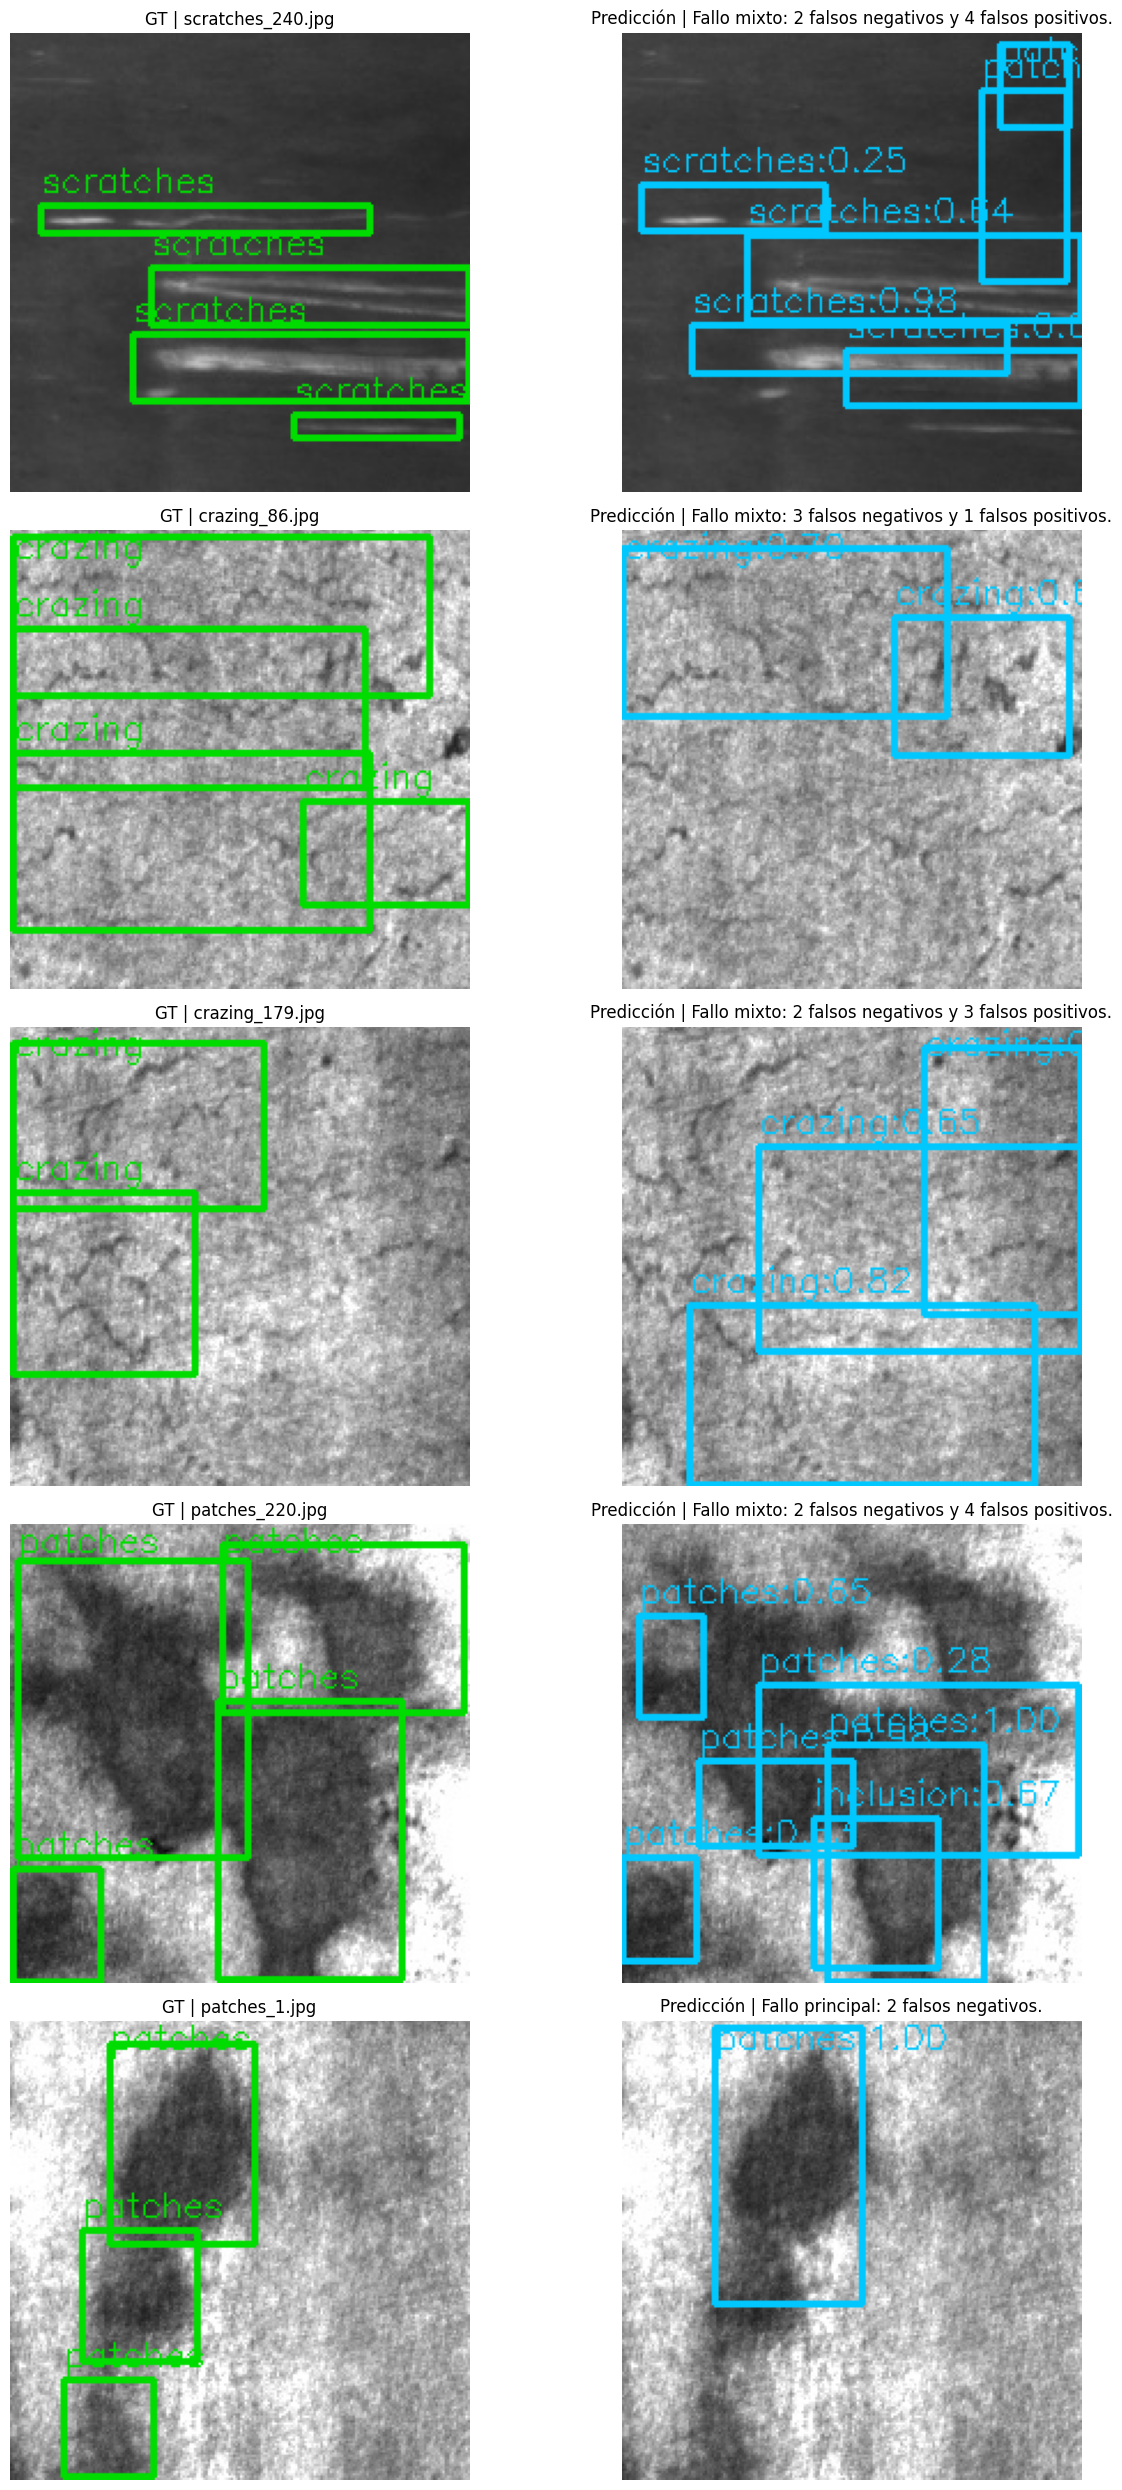

In [24]:
def draw_boxes(img_bgr, boxes, class_names, color=(0, 255, 0)):
    out = img_bgr.copy()
    for b in boxes:
        x1, y1, x2, y2 = b["box"]
        class_id = int(b["class_id"] )
        name = class_names[class_id] if class_id < len(class_names) else str(class_id)
        conf = b.get("conf", None)
        label = f"{name}" if conf is None else f"{name}:{conf:.2f}"
        cv2.rectangle(out, (x1, y1), (x2, y2), color, 2)
        cv2.putText(out, label, (x1, max(12, y1 - 6)), cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 1)
    return out


def diagnose_failure(gts, preds, iou_thr=0.5):
    if len(gts) == 0 and len(preds) == 0:
        return "Sin objetos en GT y sin predicciones."
    if len(gts) > 0 and len(preds) == 0:
        return "Fallo principal: falso negativo (no detecta defectos)."
    if len(gts) == 0 and len(preds) > 0:
        return "Fallo principal: falso positivo (detecta donde no hay defecto)."

    matched_gt = set()
    matched_pred = set()
    class_errors = 0

    for pi, p in enumerate(preds):
        best_iou = 0.0
        best_gi = -1
        for gi, g in enumerate(gts):
            if gi in matched_gt:
                continue
            iou = compute_iou(p["box"], g["box"])
            if iou > best_iou:
                best_iou = iou
                best_gi = gi

        if best_gi >= 0 and best_iou >= iou_thr:
            matched_pred.add(pi)
            matched_gt.add(best_gi)
            if preds[pi]["class_id"] != gts[best_gi]["class_id"]:
                class_errors += 1

    fn = len(gts) - len(matched_gt)
    fp = len(preds) - len(matched_pred)

    if class_errors > 0:
        return f"Fallo principal: confusión de clase ({class_errors} casos)."
    if fn > 0 and fp > 0:
        return f"Fallo mixto: {fn} falsos negativos y {fp} falsos positivos."
    if fn > 0:
        return f"Fallo principal: {fn} falsos negativos."
    if fp > 0:
        return f"Fallo principal: {fp} falsos positivos."
    return "Predicción correcta (emparejamientos IoU>=0.5)."


def show_5_real_comparisons(
    weights: Path,
    test_root: Path,
    threshold: float = 0.25,
    iou_thr: float = 0.5,
    n_show: int = 5,
    seed: int = 42,
):
    ckpt = torch.load(weights, map_location=DEVICE)
    class_names = ckpt.get("class_names", NEU_CLASSES)
    s = int(ckpt.get("s", 7))
    num_classes = int(ckpt.get("num_classes", len(class_names)))

    model = CustomSteelDetector(s=s, num_classes=num_classes).to(DEVICE)
    model.load_state_dict(ckpt["model_state_dict"])
    model.eval()

    images = list_test_images(test_root)
    if len(images) == 0:
        raise FileNotFoundError(f"No hay imágenes en {test_root}")

    rng = random.Random(seed)
    chosen = images if len(images) <= n_show else rng.sample(images, n_show)

    fig, axes = plt.subplots(len(chosen), 2, figsize=(14, 5 * len(chosen)))
    if len(chosen) == 1:
        axes = np.array([axes])

    for row, image_path in enumerate(chosen):
        raw = cv2.imread(str(image_path), cv2.IMREAD_COLOR)
        if raw is None:
            continue

        gts = load_gt_boxes_for_image(image_path)
        preds = predict_boxes_for_image(model, image_path, threshold=threshold)
        failure_text = diagnose_failure(gts, preds, iou_thr=iou_thr)

        left = draw_boxes(raw, gts, class_names, color=(0, 220, 0))
        right = draw_boxes(raw, preds, class_names, color=(255, 200, 0))

        axes[row, 0].imshow(cv2.cvtColor(left, cv2.COLOR_BGR2RGB))
        axes[row, 0].set_title(f"GT | {image_path.name}")
        axes[row, 0].axis("off")

        axes[row, 1].imshow(cv2.cvtColor(right, cv2.COLOR_BGR2RGB))
        axes[row, 1].set_title(f"Predicción | {failure_text}")
        axes[row, 1].axis("off")

    plt.tight_layout()
    plt.show()


VIS_WEIGHTS = Path("../src/custom_steel_detector_grid7.pth")
VIS_TEST_DIR = Path("../data/test")

if VIS_WEIGHTS.exists() and VIS_TEST_DIR.exists():
    show_5_real_comparisons(
        weights=VIS_WEIGHTS,
        test_root=VIS_TEST_DIR,
        threshold=0.25,
        iou_thr=0.5,
        n_show=5,
    )
else:
    print("[WARN] No se pudo ejecutar visualización: revisa VIS_WEIGHTS y VIS_TEST_DIR")